# Neural Network Architectures
## Computer Vision — Image Classification using CNNs (ResNet-18) and MLPs

Developed a computer vision pipeline for image classification, benchmarking MLP and ResNet-18 architectures with PyTorch and analyzing prediction performance and model behavior

What this project does: 

- Loads and preprocesses the [MNIST dataset](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html)
- Builds an MLP architecture
- Builds a ResNet18 architecture
- Profiles, evaluates, and compare their performance

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.transforms as T
import torchvision.models as M
from sklearn.metrics import accuracy_score, classification_report
torch.manual_seed(42)

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(f"Using device: {device}")

Using device: mps


### Loading the Data

In [2]:
# Transforming the images according to preset parameters and converting them to tensors
transform = T.Compose([
    T.Resize(28),
    T.ToTensor(),
    T.Normalize(mean = 0.1307, std = 0.3081)
])

In [3]:
train_dataset = datasets.MNIST(root = "datasets", train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root = "datasets", train = False, download = True, transform = transform)

100%|██████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 6.53MB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 335kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.95MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.07MB/s]


In [4]:
train_dataloader = DataLoader(train_dataset, batch_size = 32, shuffle =  True)
test_dataloader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

### Creating a Simple MLP Architecture from Scratch

Flow: $X \rightarrow L_1 \rightarrow \sigma \rightarrow L_2 \rightarrow \sigma \rightarrow L_3 \rightarrow \sigma$

$\sigma$ - ReLU

$L_n$ - nth layer

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.L1 = nn.Linear(input_size, hidden_size)
        self.L2 = nn.Linear(hidden_size, hidden_size)
        self.L3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
    def forward(self, X):
        X = self.flatten(X) # flattening the input size into a 1D tensor
        X = self.relu(self.L1(X))
        X = self.relu(self.L2(X))
        X = self.L3(X)
        return X

In [6]:
input_size = 28*28*1
hidden_size = 128
output_size = 10

In [7]:
mnist_mlp = SimpleMLP(input_size, hidden_size, output_size)
mnist_mlp.to(device)
from custom_torchinfo import custom_summary
custom_summary(mnist_mlp, input_size=(32, 1, 28, 28))

        Layer (type)              Output Shape         Param #
           Flatten-1                 [32, 784]               0
            Linear-2                 [32, 128]         100,480
              ReLU-3                 [32, 128]               0
            Linear-4                 [32, 128]          16,512
              ReLU-5                 [32, 128]               0
            Linear-6                  [32, 10]           1,290
         SimpleMLP-7                  [32, 10]               0
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0


### Loading the ResNet 18 Architecture

Adapted ResNet-18 for grayscale image classification by modifying the input convolution layer to accept single-channel images, removing early spatial downsampling (max pooling), and adjusting the final fully connected layer for 10-class prediction.

In [8]:
model_resnet18 = M.resnet18(weights = None)
in_feats = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(in_feats, 10) # modified last layer -> 10 outputs

model_resnet18.conv1 = nn.Conv2d(1, 64, kernel_size = 3, stride = 1, padding = 1) 
# modified the convolutional layer to accept a single channel
model_resnet18.maxpool = nn.Identity() # removed maxpool layer
model_resnet18 = model_resnet18.to(device)

from custom_torchinfo import custom_summary

custom_summary(model_resnet18, input_size=(1, 1, 28, 28))

        Layer (type)              Output Shape         Param #
            Conv2d-1           [1, 64, 28, 28]             640
       BatchNorm2d-2           [1, 64, 28, 28]             128
              ReLU-3           [1, 64, 28, 28]               0
          Identity-4           [1, 64, 28, 28]               0
            Conv2d-5           [1, 64, 28, 28]          36,864
       BatchNorm2d-6           [1, 64, 28, 28]             128
              ReLU-7           [1, 64, 28, 28]               0
            Conv2d-8           [1, 64, 28, 28]          36,864
       BatchNorm2d-9           [1, 64, 28, 28]             128
             ReLU-10           [1, 64, 28, 28]               0
       BasicBlock-11           [1, 64, 28, 28]               0
           Conv2d-12           [1, 64, 28, 28]          36,864
      BatchNorm2d-13           [1, 64, 28, 28]             128
             ReLU-14           [1, 64, 28, 28]               0
           Conv2d-15           [1, 64, 28, 28]         

### Defining the Training Function

In [9]:
def train_model(model, train_loader, num_epochs = 10, lr = 0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train() # activated training mode
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        correct, total = 0, 0
        num_batches = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            # Forward pass
            logits = model(batch_X)
            #Compute loss
            loss = criterion(logits, batch_y)
            # Reset all gradients before computing new ones
            # Clear
            optimizer.zero_grad() # Clear old gradients
            loss.backward() # Compute gradients
            optimizer.step() # Update weights using those gradients
            # Tracking loss
            epoch_loss += loss.item() # Converting the loss tensor to a Python number; accumulating loss
            num_batches += 1 # Count number of batches
            # Tracking accuracy
            preds = logits.argmax(dim=1) # Picking the class with highest score
            correct += (preds == batch_y).sum().item() # Count correct predictions
            total += batch_y.size(0) # Count how many samples
            
        # Calculating accuracy    
        avg_loss = epoch_loss / num_batches
        accuracy = correct / total
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

In [10]:
batch_X, batch_y = next(iter(train_dataloader))
print(batch_X.shape, batch_X.dtype)
print(batch_y.shape, batch_y.dtype)
print(batch_y[:10])

torch.Size([32, 1, 28, 28]) torch.float32
torch.Size([32]) torch.int64
tensor([4, 3, 1, 8, 3, 5, 8, 8, 9, 9])


In [11]:
train_model(model_resnet18, train_dataloader, num_epochs = 1, lr = 0.001)

Epoch [1/1], Loss: 0.1088, Accuracy: 0.9672


In [12]:
train_model(mnist_mlp, train_dataloader, num_epochs = 3, lr = 0.001)

Epoch [1/3], Loss: 0.2289, Accuracy: 0.9308
Epoch [2/3], Loss: 0.0996, Accuracy: 0.9688
Epoch [3/3], Loss: 0.0723, Accuracy: 0.9775


In [13]:
def predict(model, dataloader, device=device):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            logits = model(batch_X)
            preds = logits.argmax(dim=1)
            all_predictions.append(preds.cpu().numpy())
            all_labels.append(batch_y.cpu().numpy())
            
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels)
    return y_pred, y_true

### Generating Predictions

In [14]:
# Model: ResNet18
y_predictions_resnet18, y_true = predict(model_resnet18, test_dataloader, device = device)

In [15]:
print(f"ResNet 18: The First 10 Predictions: {y_predictions_resnet18[:10]}")

ResNet 18: The First 10 Predictions: [7 2 1 0 4 1 4 9 5 9]


In [16]:
print(f"ResNet 18: The First 10 Labels: {y_true[:10]}")

ResNet 18: The First 10 Labels: [7 2 1 0 4 1 4 9 5 9]


In [17]:
# Model: MLP
y_predictions_mlp, y_true = predict(mnist_mlp, test_dataloader, device = device)

In [18]:
print(f"MLP: The First 10 Predictions: {y_predictions_mlp[:10]}")

MLP: The First 10 Predictions: [7 2 1 0 4 1 4 9 5 9]


In [19]:
print(f"MLP: The First 10 Labels: {y_true[:10]}")

MLP: The First 10 Labels: [7 2 1 0 4 1 4 9 5 9]


In [20]:
print("\n=== MLP Performance ===")
accuracy_mlp = accuracy_score(y_true, y_predictions_mlp)
print(f"Test Accuracy: {accuracy_mlp:.4f}")

report_mlp = classification_report(
    y_true, 
    y_predictions_mlp,
    target_names=[str(i) for i in range(10)]
)
print(report_mlp)


print("\n=== ResNet18 Performance ===")
accuracy_resnet18 = accuracy_score(y_true, y_predictions_resnet18)
print(f"Test Accuracy: {accuracy_resnet18:.4f}")

report_resnet18 = classification_report(
    y_true, 
    y_predictions_resnet18,
    target_names=[str(i) for i in range(10)]
)
print(report_resnet18)


=== MLP Performance ===
Test Accuracy: 0.9740
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.96      0.97       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.98      0.95      0.96       974
           9       0.95      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000


=== ResNet18 Performance ===
Test Accuracy: 0.9830
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00

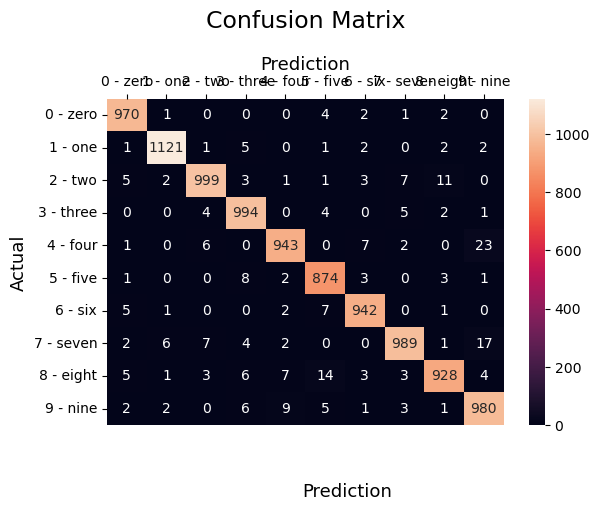

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm_mlp = confusion_matrix(y_true, y_predictions_mlp)

sns.heatmap(cm_mlp, 
            annot=True,
            fmt='g', 
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

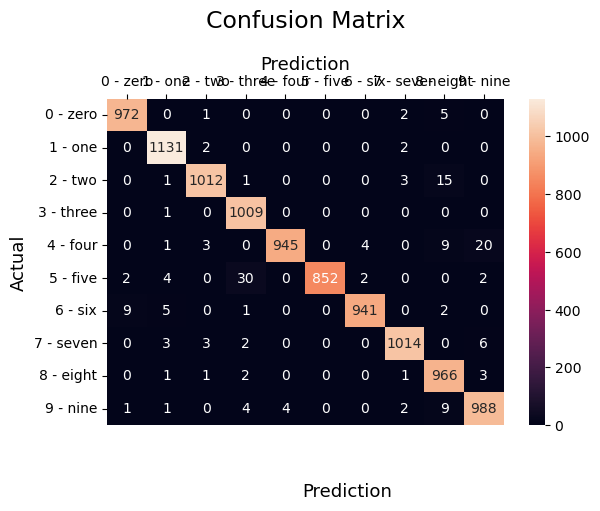

In [22]:
cm_resnet18 = confusion_matrix(y_true, y_predictions_resnet18)

sns.heatmap(cm_resnet18, 
            annot=True,
            fmt='g', 
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_resnet18)

NameError: name 'y_pred_resnet18' is not defined

## Conclusion (Part A)

Compare the results of the MLP and ResNet18 models:

a. Which model performed better?

The ResNet18 slightly outperformed the MLP across precision, recall, and F1-score, indicating better overall classification performance at the expense of time.

b. What are the advantages of CNNs over MLPs for image classification?

MLPs rely on fully connected layers and treat input pixels independently, ignoring spatial structure. In contrast, CNNs leverage convolutional layers, pooling, and localized receptive fields to capture spatial hierarchies and local patterns (e.g., edges, textures). This makes CNNs significantly more effective for image data, where spatial relationships are critical.

c. Which digits were most difficult to classify for each model?

Both models struggled most with the digit “5”, likely due to its higher visual similarity with other digits. Interestingly, the MLP slightly outperformed ResNet18 on this class, suggesting that deeper architectures do not always guarantee superior performance.